In [1]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

C:\Users\AC\AppData\Local\Temp\ipykernel_26228\1860997399.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [2]:
load_dotenv()

True

In [ ]:
# llm = ChatOpenAI()

In [3]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7
)

In [4]:
loader = PyPDFLoader("my_paper.pdf")
docs = loader.load()

In [5]:
docs

[Document(metadata={'producer': 'pdfTeX-1.40.21', 'creator': 'LaTeX with hyperref', 'creationdate': '2021-09-14T02:52:38+00:00', 'author': '', 'keywords': '', 'moddate': '2021-09-14T02:52:38+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) kpathsea version 6.3.2', 'subject': '', 'title': '', 'trapped': '/False', 'rgid': 'PB:357213035_AS:1103436619751424@1640091199662', 'source': 'my_paper.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='See discussions, stats, and author profiles for this publication at: https://www.researchgate.net/publication/357213035\nDevelopment of Multiple Combined Regression Methods for Rainfall\nMeasurement Development of Multiple Combined Regression Methods for\nRainfall Measurement\nArticle · December 2021\nCITATIONS\n0\nREADS\n711\n6 authors, including:\nNusrat Jahan Prottasha\nDaffodil International University\n26 PUBLICATIONS\xa0\xa0\xa0299 CITATIONS\xa0\xa0\xa0\nSEE PROFILE\nMd Kowsher\nSteven

In [6]:
len(docs)

15

In [7]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [8]:
len(chunks)

44

In [26]:
# embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
# vector_store = FAISS.from_documents(chunks, embeddings)

In [10]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)
vector_store = FAISS.from_documents(chunks, embeddings)
vector_store.save_local("faiss_index")

In [11]:
vector_store

In [12]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [13]:
ans = retriever.invoke("What is Rainfall Measurement?")
ans

[Document(id='cf26d32f-fc2f-4e9d-9f2e-3bc0e92fa0e8', metadata={'producer': 'pdfTeX-1.40.21', 'creator': 'LaTeX with hyperref', 'creationdate': '2021-09-14T02:52:38+00:00', 'author': '', 'keywords': '', 'moddate': '2021-09-14T02:52:38+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) kpathsea version 6.3.2', 'subject': '', 'title': '', 'trapped': '/False', 'rgid': 'PB:357213035_AS:1103436619751424@1640091199662', 'source': 'my_paper.pdf', 'total_pages': 15, 'page': 3, 'page_label': '4'}, page_content='Some of the research has shown some classiﬁcation method to predict whether\nit would be rain tomorrow or not. But instead of a classiﬁcation method for pre-\ndicting rain, we need to the quantity of the rainfall in a particular place. There\nis numerous equipment implement for foreseeing rainfall by utilizing the climate\nconditions like temperature, humidity, weight. These conventional strategies can-\nnot work productively so by utilizing machine

In [14]:
@tool
def rag_tool(query: str) -> str:
    """
    Retrieve relevant information from the PDF document.

    Use this tool when the user asks factual or conceptual questions
    that may be answered using the stored PDF documents.

    Args:
        query: The question or search query used to retrieve PDF content.
    """

    documents = retriever.invoke(query)

    if not documents:
        return "No relevant information was found in the PDF."

    formatted_documents = []

    for index, document in enumerate(documents, start=1):
        source = document.metadata.get("source", "Unknown source")
        page = document.metadata.get("page", "Unknown page")

        formatted_documents.append(
            f"Document {index}\n"
            f"Source: {source}\n"
            f"Page: {page}\n"
            f"Content: {document.page_content}"
        )

    return "\n\n".join(formatted_documents)

In [15]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [16]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [17]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

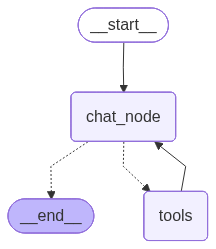

In [18]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")  
chatbot = graph.compile()

chatbot

In [19]:
# Regular chat
result = chatbot.invoke({"messages": [HumanMessage(content="Hello")]})

print(result["messages"][-1].content)

Hello! I'm here to answer your questions about the PDF document. How can I help you today?


In [20]:
# Regular chat
result = chatbot.invoke({"messages": [HumanMessage(content="Using the pdf notes, explain about Rainfall Measurement techniques in a concise way")]})

print(result["messages"][-1].content)

[{'type': 'text', 'text': 'The provided documents primarily discuss rainfall *prediction* techniques using machine learning and regression analysis, rather than detailing specific rainfall *measurement* techniques. They mention that there are conventional methods using equipment that measure climate conditions like temperature, humidity, and weight for foreseeing rainfall, but these are not described in detail. The focus of the documents is on improving rainfall prediction accuracy using historical data and various regression models.', 'extras': {'signature': 'CucFAQw51sefssDPiZBNqOOKHwjE1Igo6haUWrNqc0eutB3zjn+lTKTX+G+4plwwBh4QYUxnoRJ+pTs0KD/eGB51Zh4bncGC7dLWMkqH4i3umhumHCMIlq21ERU/Ev79iAKFsy14FDD8zbxKNCSA0qMVV0k2v5dAszC0eKSdh3wiOqSNgCltVH3EnY9pcyFJoSR1iY+KrR5hkEA9/N2ousIXy7Le2GY3F3+Sb9xac/RdxKAZNUvQogY6GZAxWIIbJSylImT5jpQDC8jNyTKJzz+961HrIfibAZ2Tq2XUbavfdtOfF2KEetYFFNY7ZKxXi2p6kRZfmCT78pgrL2Gua1w0at0CQAn8r4ZxTc8Dy4KKJMjMPzLgjyv2/EdO7q15zSMlwKUUtNuYUyPCgJwEg0FzyQ9GnyZMh4alONKfF7dEwcbVS

In [21]:
print(result["messages"][-1].content[0]["text"])

The provided documents primarily discuss rainfall *prediction* techniques using machine learning and regression analysis, rather than detailing specific rainfall *measurement* techniques. They mention that there are conventional methods using equipment that measure climate conditions like temperature, humidity, and weight for foreseeing rainfall, but these are not described in detail. The focus of the documents is on improving rainfall prediction accuracy using historical data and various regression models.
